# *Supervised learning*

# *Importing Libraries*

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time
import warnings
warnings.filterwarnings('ignore')

# *Reading Data*

In [153]:
tele = pd.read_csv('/content/New Data.csv')
tele = pd.DataFrame(tele)

# *Exploring Data*

In [154]:
tele

,SINR,RSRP,RSRQ,RSSI,DL,UL,RSSI_RSRP_ratio,delta_SINR,rolling_sinr_5,Normal_traffic
0,19.518991,NaN,-5.974752,-74.298841,28.539769,5.843383,-0.837953,0.000000,19.518991,1
1,11.646554,NaN,-9.728186,-88.709072,45.117216,7.343139,-0.930877,-7.872437,NaN,1
2,-4.541216,-79.414832,-9.684904,-54.723843,NaN,4.268691,-0.689088,-16.187771,NaN,0
3,-0.233241,NaN,-17.928034,-75.852129,0.572894,0.780961,-0.798046,4.307975,6.597772,0
4,26.969629,-83.767266,-10.870791,-72.778106,29.132254,8.871080,-0.868813,27.202871,10.672144,1
...,...,...,...,...,...,...,...,...,...,...
6065,13.307979,-85.151132,-6.334659,NaN,17.671868,5.003807,-0.854829,-4.125269,16.152790,1
6066,11.340786,NaN,-7.482254,-80.949248,26.486011,14.436538,-0.892501,-1.967193,13.917694,1
6067,-10.710809,-85.247469,-17.048067,-67.772313,2.371799,6.709342,-0.795007,-22.051595,7.438532,0
6068,26.019288,-100.892750,-10.571201,-93.319529,31.231201,9.326020,-0.924938,NaN,11.478098,1


In [155]:
tele.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6070 entries, 0 to 6069
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SINR             5342 non-null   float64
 1   RSRP             5342 non-null   float64
 2   RSRQ             5342 non-null   float64
 3   RSSI             5342 non-null   float64
 4   DL               5342 non-null   float64
 5   UL               5342 non-null   float64
 6   RSSI_RSRP_ratio  5342 non-null   float64
 7   delta_SINR       5342 non-null   float64
 8   rolling_sinr_5   5342 non-null   float64
 9   Normal_traffic   6070 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 474.3 KB


In [156]:
tele.describe()

,SINR,RSRP,RSRQ,RSSI,DL,UL,RSSI_RSRP_ratio,delta_SINR,rolling_sinr_5,Normal_traffic
count,5342.000000,5342.000000,5342.000000,5342.000000,5342.000000,5342.000000,5342.000000,5342.000000,5342.000000,6070.000000
mean,13.897473,-85.099687,-9.675593,-73.292347,19.901043,6.251387,-0.860785,0.013884,13.915764,0.767875
std,9.762017,6.141544,3.466165,8.358786,13.015506,3.454782,0.067600,13.895238,4.315744,0.422223
min,-20.672865,-108.019933,-26.813382,-102.912099,0.000000,0.000000,-1.048980,-43.994471,-1.646447,0.000000
25%,8.884576,-89.344643,-11.656748,-78.995587,6.706951,3.939076,-0.906643,-8.652266,11.070467,1.000000
50%,15.791295,-85.147575,-9.431372,-73.589246,21.360544,6.523121,-0.869696,-0.028937,14.060628,1.000000
75%,20.749399,-80.845641,-7.370043,-68.041645,29.625935,8.663088,-0.825660,8.629364,16.989720,1.000000
max,41.557426,-63.825669,1.133305,-39.748945,64.423310,17.411100,-0.553300,45.974244,26.688753,1.000000


# *Preprocessing*

In [157]:
tele.duplicated().sum()

np.int64(0)

In [158]:
tele.isnull().sum()

,0
SINR,728
RSRP,728
RSRQ,728
RSSI,728
DL,728
UL,728
RSSI_RSRP_ratio,728
delta_SINR,728
rolling_sinr_5,728
Normal_traffic,0


In [159]:
df_filled = tele.fillna(tele.median())

In [160]:
X = df_filled.drop('Normal_traffic', axis=1)
y = df_filled['Normal_traffic']

In [161]:
scaler = StandardScaler()
data_scaled  = scaler.fit_transform(X)
data_scaled  = pd.DataFrame(data_scaled , columns=tele.drop('Normal_traffic', axis=1).columns)
data_scaled.head(10)

,SINR,RSRP,RSRQ,RSSI,DL,UL,RSSI_RSRP_ratio,delta_SINR,rolling_sinr_5
0,0.587770,-0.007316,1.128896,-0.123816,0.692714,-0.135907,0.376519,-0.000671,1.379709
1,-0.270007,-0.007316,-0.025177,-1.961530,2.049503,0.326711,-1.087392,-0.604656,0.031490
2,-2.033820,0.987784,-0.011869,2.372553,0.105127,-0.621639,2.721705,-1.242620,0.031490
3,-1.564425,-0.007316,-2.546394,-0.321904,-1.596248,-1.697470,1.005205,0.329843,-1.811840
4,1.399588,0.232281,-0.376495,0.070121,0.741206,0.798022,-0.109645,2.086373,-0.805468
5,-0.313905,-1.668052,-0.718872,-0.092920,0.648877,2.204305,1.259754,-1.207189,-1.214269
6,-1.531870,1.093168,-1.424089,-0.033322,0.105127,0.073767,1.560095,-0.002891,-1.786373
7,0.181602,-2.577937,-1.006966,-2.569392,1.181623,-0.078523,-1.154844,-0.002891,-0.358668
8,-0.316887,-0.173908,1.917056,-0.414912,0.398571,0.573846,-0.433528,-1.009045,0.206941
9,0.181602,0.563233,1.257734,0.455413,-1.003850,0.032284,0.152994,0.048228,-0.539789


In [162]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# *Evaluation*

In [163]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [164]:
models = {
    "SVM (linear)": SVC(kernel='linear', probability=False),
    "SVM (poly)": SVC(kernel='poly', probability=False , degree=2),
    "SVM (rbf)": SVC(kernel='rbf', probability=False),

    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42,max_depth=8),
    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Naive Bayes(Gaussian)": GaussianNB(),
    "Naive Bayes(Bernoulli)": BernoulliNB(),
    "Naive Bayes(Multinomial)": MultinomialNB()}

In [165]:
results = []

for name, clf in models.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')), # Impute missing values
        ('scaler', MinMaxScaler()),
        ('classifier', clf)
    ])

    start = time.perf_counter()
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    end = time.perf_counter()
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    duration = end - start

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "Time(s)": duration
    })

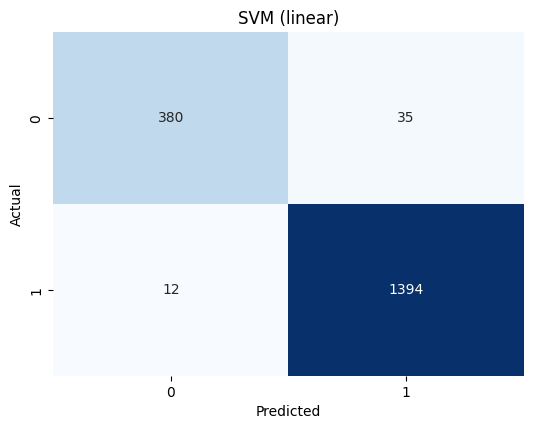

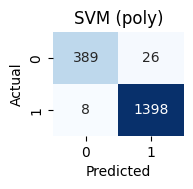

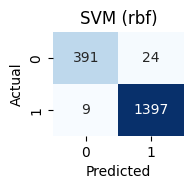

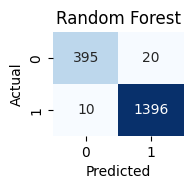

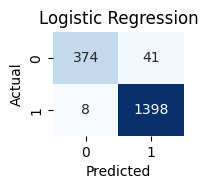

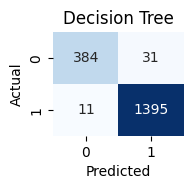

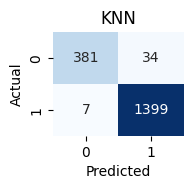

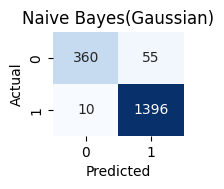

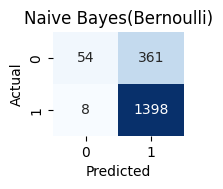

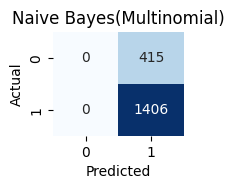

In [166]:
from sklearn.metrics import ConfusionMatrixDisplay

n_models = len(models)
n_cols = 4
n_rows = (n_models + n_cols - 1) // n_cols

plt.figure(figsize=(5*n_cols, 4*n_rows))
plot_index = 1
for name, clf in models.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', MinMaxScaler()),
        ('classifier', clf)
    ])
    pipeline.fit(X_train, y_train) # Fit the pipeline again to get predictions for plotting
    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    ax = plt.subplot(n_rows, n_cols, plot_index)  # 3 rows x 4 columns to accommodate all 10 plots
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

In [167]:
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
print("\n\t\t\t\t=== Comparison ===")
print(results_df)


				=== Comparison ===
                      Model  Accuracy  Precision    Recall        F1   Time(s)
0             Random Forest  0.983526   0.985876  0.992888  0.989369  1.468474
1                 SVM (rbf)  0.981878   0.983110  0.993599  0.988327  0.120118
2                SVM (poly)  0.981329   0.981742  0.994310  0.987986  0.096757
3                       KNN  0.977485   0.976274  0.995021  0.985558  0.097431
4             Decision Tree  0.976936   0.978261  0.992176  0.985169  0.088448
5              SVM (linear)  0.974190   0.975507  0.991465  0.983422  0.095950
6       Logistic Regression  0.973092   0.971508  0.994310  0.982777  0.017425
7     Naive Bayes(Gaussian)  0.964305   0.962095  0.992888  0.977249  0.008464
8    Naive Bayes(Bernoulli)  0.797364   0.794770  0.994310  0.883412  0.010435
9  Naive Bayes(Multinomial)  0.772103   0.772103  1.000000  0.871398  0.010329


In [168]:
train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)
print("Train:", train_acc, " Test:", test_acc)

Train: 0.7660626029654036  Test: 0.7721032399780341
